In [2]:
import sys
sys.path.append('../')
import scipy as sp


import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
import qutip as qt
import scqubits as scq
from scipy.ndimage import gaussian_filter
from IPython.display import display, Math

#### Drag in 4-level system

In [3]:
drive_phi, drive_theta = False, True
truc1 = 30
hilbert_space = [0,2,7,25]
n_cpu = 6

In [4]:
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 100)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=30, truncated_dim=truc1)
n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc1)
n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc1)
n_Phi = 2*np.pi * qt.Qobj(n_phi)
n_Theta = 2*np.pi * qt.Qobj(n_theta)

evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc1)
H0 = qt.Qobj(np.diag(evals))
if drive_phi:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = n_Phi
if drive_theta:
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    drive_term = n_Theta
if drive_phi and drive_theta:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = 0.976*n_Phi+ 0.024*n_Theta

In [5]:
w_0_7 = w_trans_1 / (2*np.pi)
w_7_25 = (evals[25] - evals[7]) / (2*np.pi)
alpha = -1 / (w_0_7 - w_7_25)

display(Math(r"\omega_{0-7} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_0_7, w_0_7*2*np.pi)  ))
display(Math(r"\omega_{7-25} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_7_25, w_7_25*2*np.pi)  ))
display(Math(r"\alpha = %.3f/2\pi = %.3f" %(alpha,   alpha/(2*np.pi))))
# r = n_theta[7,25]/n_theta[7,0]
# beta = - 0.25* r**2/(w_0_7 - w_7_25)
# display(Math(r"\beta = %.3f GHz" %beta  ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Get fidelity

In [64]:
# tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 1, 0.093468, 0, 0.171969, 0, 0]
# tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 0.418621, 0.093468, 0.169464, 0.171969, 0, 0]
# tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 0.374488, 0.170669, 0.240864, 0.1934, -1.264711, 0]

# tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [19.884099, 0.387823, 0.151723, 0.209111, 0.191829, 1.492099, 0]

# limit A < 1
tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [19.912277, 0.652689, 0.146696, 0.37051, 0.358067, 0.0, 0.0]

# limit A < 0.5
tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [ 19.768963, 0.499855, 0.205195, 0.351834, 0.314633, 0.0, 0.0]

# argz = [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
#         drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B]
# fidelity = ut.xgate_fidelity(argz)
# print('fidelity_alpha = ', fidelity)

In [65]:
# tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 0.418621, 0.093468, 0.169464, 0.171969, 0, 0]
def drag_A(t: float, args: dict) -> float:
    A = args.get('drive_amp_A', 0)
    wd = args.get('drive_freq_A', 0)
    tg = args.get('gate_time', 0)
    alpha = args.get('alpha_A', 0)
    vg = A * (np.exp(-8 * t * (t - tg) / tg**2) - 1)
    # The + A in the second term is new
    return  vg* np.cos(wd* t)* (0<=t<=tg) + alpha* (vg + A) * (-8*(2*t-tg)/tg**2)* np.sin(wd* t)* (0<=t<=tg)

drive_freq = w_trans_1 + 2*np.pi*detune_A
print('drive_freq=', drive_freq/(2*np.pi))
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': drive_freq, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        'alpha_A': alpha_A}
# tlist = np.linspace(0, tg,  num=int(500*tg))  # total time
buffer = 5
tlist = np.linspace(-buffer*tg, (buffer+1)*tg,  num=int(10000*tg))  # total time


pulse = np.array([ut.drive_gauss_A(t, pulse_args) for t in tlist])
# pulse_drag = np.array([ut.drag_A(t, pulse_args) for t in tlist])
pulse_drag = np.array([drag_A(t, pulse_args) for t in tlist])


def make_ps(pulse):
        # Power spectrum of pulse
        mag = np.fft.fftshift(np.abs(np.fft.fft(pulse)))
        freqs = np.fft.fftshift(np.fft.fftfreq(pulse.size, tlist[1]-tlist[0]))
        peak_loc = np.argmin(np.abs(freqs-drive_freq/(2*np.pi)))
        ps_db = 20*np.log10(mag/mag[peak_loc])
        return mag, freqs, peak_loc, ps_db

mag, freqs, peak_loc, ps_db = make_ps(pulse)
mag_drag, freqs_drag, peak_loc_drag, ps_db_drag = make_ps(pulse_drag)

drive_freq= 7.334543855261988


#### Drag vs. No DRAG for optimized pulse

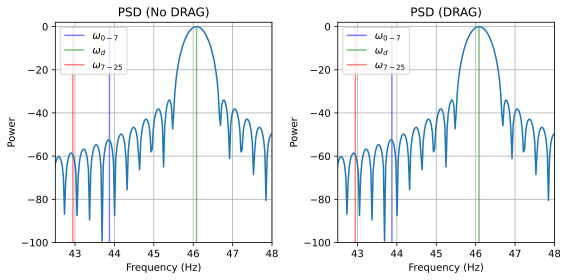

In [66]:
f, ax = plt.subplots(ncols=2, figsize=(8,4))

# xlim = [44, 47]
# ylim = [-50, 2]

xlim = [42.5, 48]
ylim = [-100, 2]



ax[0].vlines(w_0_7*(2*np.pi), -120, 0, colors = "blue", linestyles = "-", alpha=0.5, label=r"$\omega_{0-7}$")
ax[0].vlines(drive_freq, -120, 0, colors = "green", linestyles = "-", alpha=0.5, label=r"$\omega_{d}$")
if alpha_A != 0:
    ax[0].vlines(drive_freq - 1/alpha_A, -120, 0, colors = "olive", linestyles = "-", alpha=0.5, label=r"$\omega_{d} - 1/\alpha$")
ax[0].vlines(w_7_25*(2*np.pi), -120, 0, colors = "red", linestyles = "-", alpha=0.5, label=r"$\omega_{7-25}$")
ax[0].plot(2*np.pi*freqs, ps_db)
ax[0].set_title("PSD (No DRAG)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_xlim(*xlim)
ax[0].set_ylim(*ylim)
ax[0].grid()
ax[0].set_ylabel("Power")

ax[1].vlines(w_0_7*(2*np.pi), -120, 0, colors = "blue", linestyles = "-", alpha=0.5, label=r"$\omega_{0-7}$")
ax[1].vlines(drive_freq, -120, 0, colors = "green", linestyles = "-", alpha=0.5, label=r"$\omega_{d}$")
if alpha_A != 0:
    ax[1].vlines(drive_freq - 1/alpha_A, -120, 0, colors = "olive", linestyles = "-", alpha=0.5, label=r"$\omega_{d} - 1/\alpha$")
ax[1].vlines(w_7_25*(2*np.pi), -120, 0, colors = "red", linestyles = "-", alpha=0.5, label=r"$\omega_{7-25}$")
ax[1].plot(2*np.pi*freqs, ps_db_drag)
ax[1].set_title("PSD (DRAG)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_xlim(*xlim)
ax[1].set_ylim(*ylim)
ax[1].grid()
ax[1].set_ylabel("Power")

for i in range(2):
    ax[i].legend()

plt.tight_layout();

#### Try putting notch at $\omega_{7-25}$

In [9]:
alpha_guess = -(1/(w_7_25*2*np.pi - drive_freq))
print("Guess for alpha", alpha_guess)
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': drive_freq, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        'alpha_A': alpha_guess}
# tlist = np.linspace(0, tg,  num=int(500*tg))  # total time
buffer = 5
tlist = np.linspace(-buffer*tg, (buffer+1)*tg,  num=int(10000*tg))  # total time


# pulse_drag = np.array([ut.drag_A(t, pulse_args) for t in tlist])
pulse_drag = np.array([drag_A(t, pulse_args) for t in tlist])


def make_ps(pulse):
        # Power spectrum of pulse
        mag = np.fft.fftshift(np.abs(np.fft.fft(pulse)))
        freqs = np.fft.fftshift(np.fft.fftfreq(pulse.size, tlist[1]-tlist[0]))
        peak_loc = np.argmin(np.abs(freqs-drive_freq/(2*np.pi)))
        ps_db = 20*np.log10(mag/mag[peak_loc])
        return mag, freqs, peak_loc, ps_db

mag, freqs, peak_loc, ps_db = make_ps(pulse)
mag_drag, freqs_drag, peak_loc_drag, ps_db_drag = make_ps(pulse_drag)

Guess for alpha 0.40956440194097143


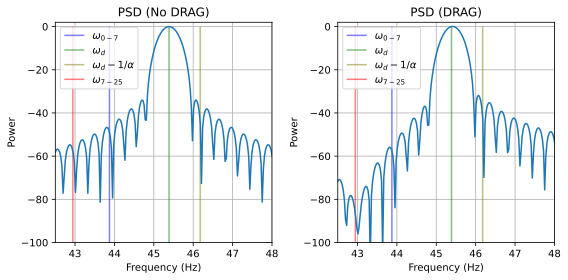

In [10]:
f, ax = plt.subplots(ncols=2, figsize=(8,4))

# xlim = [44, 47]
# ylim = [-50, 2]

xlim = [42.5, 48]
ylim = [-100, 2]

ax[0].vlines(w_0_7*(2*np.pi), -120, 0, colors = "blue", linestyles = "-", alpha=0.5, label=r"$\omega_{0-7}$")
ax[0].vlines(drive_freq, -120, 0, colors = "green", linestyles = "-", alpha=0.5, label=r"$\omega_{d}$")
ax[0].vlines(drive_freq - 1/alpha_A, -120, 0, colors = "olive", linestyles = "-", alpha=0.5, label=r"$\omega_{d} - 1/\alpha$")
ax[0].vlines(w_7_25*(2*np.pi), -120, 0, colors = "red", linestyles = "-", alpha=0.5, label=r"$\omega_{7-25}$")
ax[0].plot(2*np.pi*freqs, ps_db)
ax[0].set_title("PSD (No DRAG)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_xlim(*xlim)
ax[0].set_ylim(*ylim)
ax[0].grid()
ax[0].set_ylabel("Power")

ax[1].vlines(w_0_7*(2*np.pi), -120, 0, colors = "blue", linestyles = "-", alpha=0.5, label=r"$\omega_{0-7}$")
ax[1].vlines(drive_freq, -120, 0, colors = "green", linestyles = "-", alpha=0.5, label=r"$\omega_{d}$")
ax[1].vlines(drive_freq - 1/alpha_A, -120, 0, colors = "olive", linestyles = "-", alpha=0.5, label=r"$\omega_{d} - 1/\alpha$")
ax[1].vlines(w_7_25*(2*np.pi), -120, 0, colors = "red", linestyles = "-", alpha=0.5, label=r"$\omega_{7-25}$")
ax[1].plot(2*np.pi*freqs, ps_db_drag)
ax[1].set_title("PSD (DRAG)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_xlim(*xlim)
ax[1].set_ylim(*ylim)
ax[1].grid()
ax[1].set_ylabel("Power")

for i in range(2):
    ax[i].legend()

plt.tight_layout();

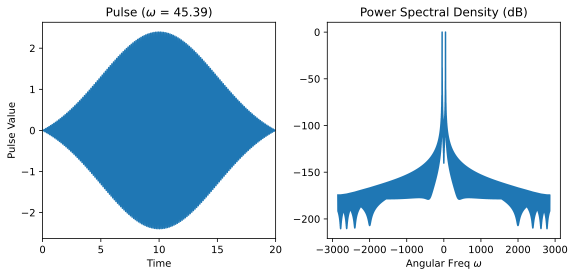

In [11]:
# Plot spectrum and pulse
f, ax = plt.subplots(ncols = 2, figsize=(8, 4))
ax[0].plot(tlist, pulse)
ax[0].set_xlim(0, tg)
# ax[1].vlines(drive_freq, -100, 1, colors = "gray", linestyles = "--")
ax[1].plot(2*np.pi*freqs, ps_db)
window = 0.5
xlim = [drive_freq - window, drive_freq + window]
# ax[1].set_xlim(-5, 10)
# ax[1].set_ylim(-20, 1)
# ax[1].set_ylim(np.min(ps_db[np.argmin(np.abs(2*np.pi*freqs-xlim[0])):peak_loc]),
#                0.5+ps_db[peak_loc])
ax[0].set_title(f"Pulse ($\omega$ = {np.round(drive_freq, 2)})")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Pulse Value")
ax[1].set_title("Power Spectral Density (dB)")
ax[1].set_xlabel(r"Angular Freq $\omega$")
plt.tight_layout();

#### Population transfer

In [67]:
# alpha_guess = -(1/(w_7_25*2*np.pi - drive_freq))
alpha_guess = alpha_A
print("Guess for alpha", alpha_guess)
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': drive_freq, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        'alpha_A': alpha_guess}

H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, drag_A],
                        [drive_truc, ut.drive_gauss_B],]

truc2 = len(hilbert_space)
states = [qt.basis(truc2, i) for i in range(truc2)]

options = qt.Options(store_states=True)
result = {}
index_2state = hilbert_space.index(2)
logi_state = [0, index_2state]
tlist_se = np.linspace(0, tg, 200)
for jdx, state_j in enumerate(logi_state):
    result[jdx] = qt.mesolve(
        H_qbt_drive,
        states[state_j],
        tlist_se,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=options  )

Guess for alpha 0.0


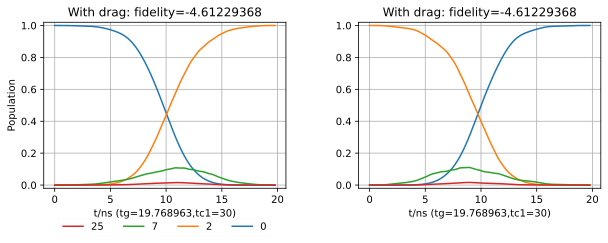

In [77]:
#####################################################################################
##### Drive and Population Visualization #######
x = [drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, tg]
args = [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, tg, drag]
fidelity = ut.xgate_fidelity_optimize(x, *args)
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        ax[jdx].plot(tlist_se, gaussian_filter( np.array(res).flatten(), 3) , label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    ax[jdx].set_ylim(-0.02,1.02)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't/ns (tg={tg},tc1={truc1})')
    ax[jdx].set_title('With drag: fidelity=%.8f'%fidelity)
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

#### Population integral

pop integral (25): 0.8809


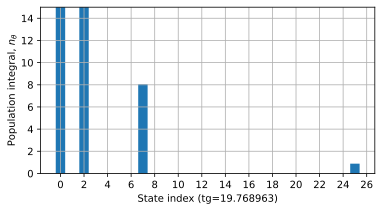

In [78]:
pop_max = []
pop_integral = []
for i in range(truc2):
    pop_integral.append( np.round( np.trapz(result[0].expect[i]), 4) )
    # print(i, hilbert_space[i], pop_integral[i])
fig, ax = plt.subplots(figsize=(6,3))
plt.bar(hilbert_space, pop_integral)
plt.ylim(0,15)
# plt.ylim(0,7.5)
# plt.xlim(-1,50)
plt.xlabel(f'State index (tg={tg})')
plt.grid()
plt.xticks(np.arange(0, 27, 2))  # Set custom x-axis ticks
# plt.title('With drag: fidelity=%.7f'%fidelity, fontsize=15)
plt.ylabel('Population integral, $n_\\theta$')
# plt.yscale("log")
print("pop integral (25):", pop_integral[hilbert_space.index(25)])
plt.show()

pop integral (25): 1.3718


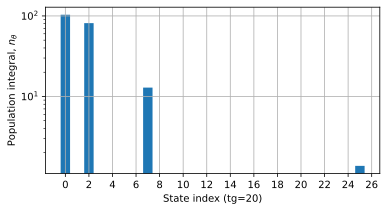

In [15]:
pop_max = []
pop_integral = []
for i in range(truc2):
    pop_integral.append( np.round( np.trapz(result[0].expect[i]), 4) )
    # print(i, hilbert_space[i], pop_integral[i])
fig, ax = plt.subplots(figsize=(6,3))
plt.bar(hilbert_space, pop_integral)
# plt.ylim(0,7.5)
# plt.xlim(-1,50)
plt.xlabel(f'State index (tg={tg})')
plt.grid()
plt.xticks(np.arange(0, 27, 2))  # Set custom x-axis ticks
# plt.title('With drag: fidelity=%.7f'%fidelity, fontsize=15)
plt.ylabel('Population integral, $n_\\theta$')
plt.yscale("log")
print("pop integral (25):", pop_integral[hilbert_space.index(25)])
plt.show()

pop integral (25): 1.3718


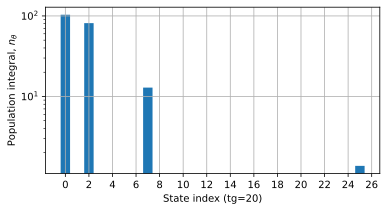

In [16]:
pop_max = []
pop_integral = []
for i in range(truc2):
    pop_integral.append( np.round( np.trapz(result[0].expect[i]), 4) )
    # print(i, hilbert_space[i], pop_integral[i])
fig, ax = plt.subplots(figsize=(6,3))
plt.bar(hilbert_space, pop_integral)
# plt.ylim(0,7.5)
# plt.xlim(-1,50)
plt.xlabel(f'State index (tg={tg})')
plt.grid()
plt.xticks(np.arange(0, 27, 2))  # Set custom x-axis ticks
# plt.title('With drag: fidelity=%.7f'%fidelity, fontsize=15)
plt.ylabel('Population integral, $n_\\theta$')
print("pop integral (25):", pop_integral[hilbert_space.index(25)])
plt.yscale("log")
plt.show()

#### Optimization

In [79]:
truc1 = 30
drive_phi, drive_theta, drag = False, True, 1
[H0, drive_term, w_trans_1, w_trans_2, hspace_charge] = ut.zero_pi_initialize(drive_phi, drive_theta, truncation=truc1,)
hilbert_space = [0,2,7,25]
amp_bounds, detune_bounds, alpha_bounds, tg_bounds = [(0, 1), (-0.5, 0.5), (0, 0), (20, 20)]
tg_vec = [20]
workers, popsize = 200, 25
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.9)]
if drag == 0:
    bounds = (amp_bounds, amp_bounds, detune_bounds, detune_bounds, tg_bounds)
else:
    bounds = (amp_bounds, amp_bounds, detune_bounds, detune_bounds, alpha_bounds, tg_bounds)

In [ ]:
fidelity = []
drive_param = []
# x0_drag = [0.414148, 0.098431, 0.1705052, 0.173006, -1/(w_7_25*2*np.pi-(w_0_7*2*np.pi+2*np.pi*0.1705052)), 20]
x0_drag = [0.387823, 0.151723, 0.209111, 0.191829, 1.492099, 19.884099]
# x0_no_drag = [0.418621, 0.093468, 0.169464, 0.171969, 0, 20]
x0_no_drag = [0.579257, 0.110622, 0.270173, 0.2727, 0.0, 20.0]
# x0_no_drag = [0.499855, 0.205195, 0.351834, 0.314633, 0.0, 19.768963]
for jdx, tg in enumerate(tg_vec):
    args = [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, tg, drag]
    res = sp.optimize.differential_evolution(
        func=ut.xgate_fidelity_optimize,
        bounds=bounds,
        args=args,
        disp=True,
        callback=ut.print_soln,
        init="sobol",
        workers=workers,
        popsize=popsize,
        mutation=mutation,
        recombination=recombination,
        tol=tol,
        x0=x0_no_drag,
        polish=False, # 'True' will make the for-loop break
        )
    fidelity.append(res.fun)
    drive_param.append(res.x)

    ### print fidelity for truc=44
    print(res, '\n')
    print('\ntg = ', np.array(tg_vec[:jdx+1]).tolist())

    print('\nlog of gate error (truc2=44) = ')
    for i in range(0, len(fidelity), 4):
        print(', '.join(map(str, np.round(fidelity[i:i+4], 8))), ',')

    fidelity_real = 1-10**np.array(fidelity)
    print('\nfidelity =  (truc2=44) ')
    for i in range(0, len(fidelity), 4):
        print(', '.join(map(str, np.round(fidelity_real[i:i+4], 8))), ',')

    print('\ndrive_param = ')
    for i in drive_param:
        print(np.round(i,6).tolist(),',')

 /home/eweissler/anaconda3/envs/enum/lib/python3.11/site-packages/scipy/optimize/_differentialevolution.py: 387

In [75]:
x0_no_drag = [0.499855, 0.205195, 0.351834, 0.314633, 0.0, 19.768963]
ut.xgate_fidelity_optimize(x0_no_drag, *args)

-4.612293684484513

In [33]:
-1/(w_7_25*2*np.pi-(w_0_7*2*np.pi+2*np.pi*0.1705052))

0.500114758578611